In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
import numpy as np
np.random.seed(10)
products = ["Laptop", "Mobile", "Tablet", "Headphones", "Chair",
            "Table", "Shoes", "Shirt"]
categories = ["Clothing", "Electronics", "Furniture", "Electronics",
              "Furniture", "Clothing", "Electronics", "Clothing"]
locations = ["Delhi", "Mumbai", "Jaipur", "Agra", "Lucknow"]
data = pd.DataFrame({
    "Order_ID": range(1, 401),
    "Product": np.random.choice(products, 400),
    "Location": np.random.choice(locations, 400),
    "Quantity": np.random.randint(1, 6, 400),
    "Discount": np.random.randint(0, 31, 400),
    "Order_Date": pd.date_range("2025-01-01", periods=400, freq="D")
})
data["Category"] = data["Product"].map(
    dict(zip(products, categories))
)
price = {
    "Laptop": 50000,
    "Mobile": 30000,
    "Tablet": 20000,
    "Headphones": 3000,
    "Chair": 5000,
    "Table": 10000,
    "Shoes": 3000,
    "Shirt": 1500
}
data["Unit_Price"] = data["Product"].map(price)
data["Sales"] = (
    data["Quantity"] *
    data["Unit_Price"] *
    (1 - data["Discount"] / 100)
)
data["Profit"] = data["Sales"] * np.random.uniform(
    0.10, 0.25, 400
)
print(data.head())

   Order_ID Product Location  Quantity  Discount Order_Date     Category  \
0         1  Mobile   Mumbai         5        11 2025-01-01  Electronics   
1         2   Table  Lucknow         1        29 2025-01-02     Clothing   
2         3   Chair    Delhi         2        27 2025-01-03    Furniture   
3         4   Shirt    Delhi         4         5 2025-01-04     Clothing   
4         5  Laptop   Mumbai         2         3 2025-01-05     Clothing   

   Unit_Price     Sales        Profit  
0       30000  133500.0  26235.163003  
1       10000    7100.0   1470.448812  
2        5000    7300.0   1689.531460  
3        1500    5700.0    659.032911  
4       50000   97000.0  19429.781726  


In [4]:
data.head()

,Order_ID,Product,Location,Quantity,Discount,Order_Date,Category,Unit_Price,Sales,Profit
0,1,Mobile,Mumbai,5,11,2025-01-01,Electronics,30000,133500.0,26235.163003
1,2,Table,Lucknow,1,29,2025-01-02,Clothing,10000,7100.0,1470.448812
2,3,Chair,Delhi,2,27,2025-01-03,Furniture,5000,7300.0,1689.531460
3,4,Shirt,Delhi,4,5,2025-01-04,Clothing,1500,5700.0,659.032911
4,5,Laptop,Mumbai,2,3,2025-01-05,Clothing,50000,97000.0,19429.781726


In [5]:
print(data.shape)

(400, 10)


In [6]:
print(data.columns)

Index(['Order_ID', 'Product', 'Location', 'Quantity', 'Discount', 'Order_Date',
       'Category', 'Unit_Price', 'Sales', 'Profit'],
      dtype='object')


In [7]:
print(data.isnull().sum())

Order_ID      0
Product       0
Location      0
Quantity      0
Discount      0
Order_Date    0
Category      0
Unit_Price    0
Sales         0
Profit        0
dtype: int64


In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order_ID    400 non-null    int64         
 1   Product     400 non-null    object        
 2   Location    400 non-null    object        
 3   Quantity    400 non-null    int64         
 4   Discount    400 non-null    int64         
 5   Order_Date  400 non-null    datetime64[ns]
 6   Category    400 non-null    object        
 7   Unit_Price  400 non-null    int64         
 8   Sales       400 non-null    float64       
 9   Profit      400 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 31.4+ KB


In [10]:
total_sales=data["Sales"].sum()
print("Total Sales =", round(total_sales, 2))

Total Sales = 17103280.0


In [11]:
total_quantity = data["Quantity"].sum()
print("Total Quantity Sold =", total_quantity)

Total Quantity Sold = 1229


In [12]:
total_profit = data["Profit"].sum()
print("Total Profit =", round(total_profit, 2))

Total Profit = 2964163.55


In [13]:
product_sales = data.groupby("Product")["Sales"].sum()
print(product_sales)
best_product = product_sales.idxmax()
print("Best Selling Product =", best_product)

Product
Chair          563750.0
Headphones     391830.0
Laptop        7687500.0
Mobile        4139100.0
Shirt          175740.0
Shoes          443160.0
Table         1321200.0
Tablet        2381000.0
Name: Sales, dtype: float64
Best Selling Product = Laptop


In [14]:
category_sales = data.groupby("Category")["Sales"].sum()
print(category_sales)

Category
Clothing       9184440.0
Electronics    4974090.0
Furniture      2944750.0
Name: Sales, dtype: float64


In [15]:
location_sales = data.groupby("Location")["Sales"].sum()
print(location_sales)

Location
Agra       2754185.0
Delhi      3281210.0
Jaipur     5697380.0
Lucknow    2295095.0
Mumbai     3075410.0
Name: Sales, dtype: float64


In [16]:
data["Order_Date"] = pd.to_datetime(data["Order_Date"])

In [17]:
data["Month"] = data["Order_Date"].dt.month

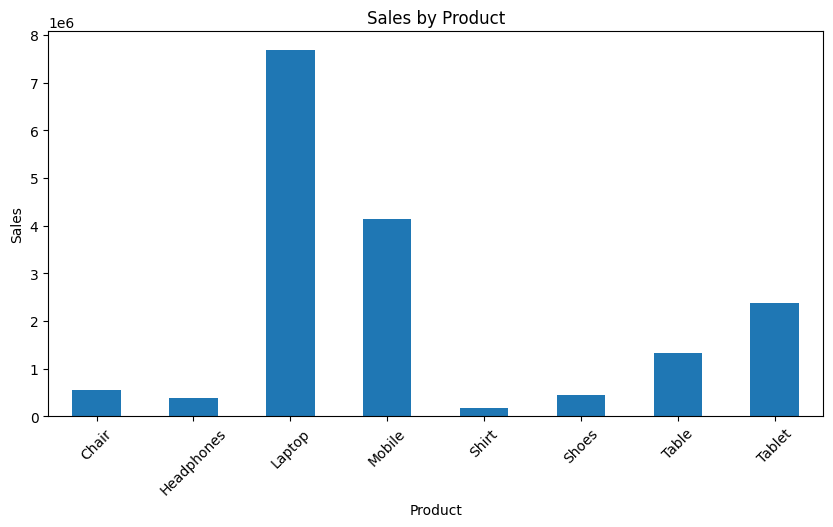

In [18]:
product_sales.plot(kind="bar", figsize=(10,5))
plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

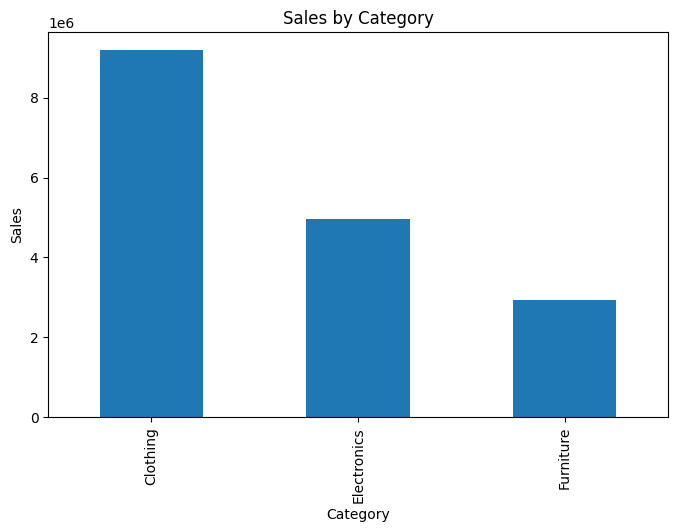

In [19]:
category_sales.plot(kind="bar", figsize=(8,5))
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

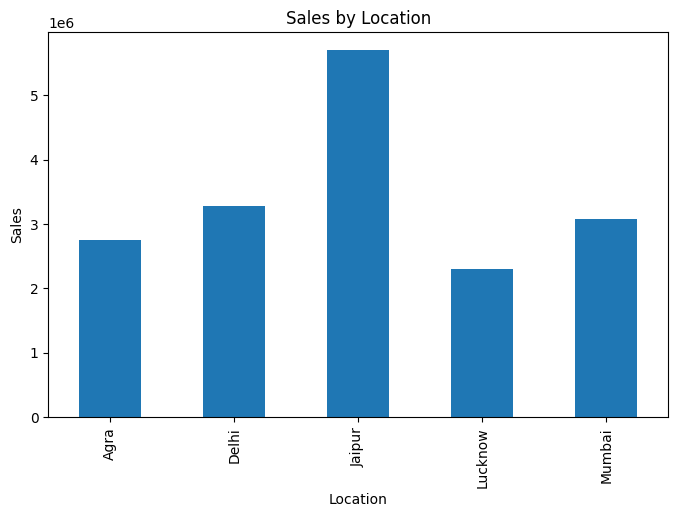

In [20]:
location_sales.plot(kind="bar", figsize=(8,5))
plt.title("Sales by Location")
plt.xlabel("Location")
plt.ylabel("Sales")
plt.show()

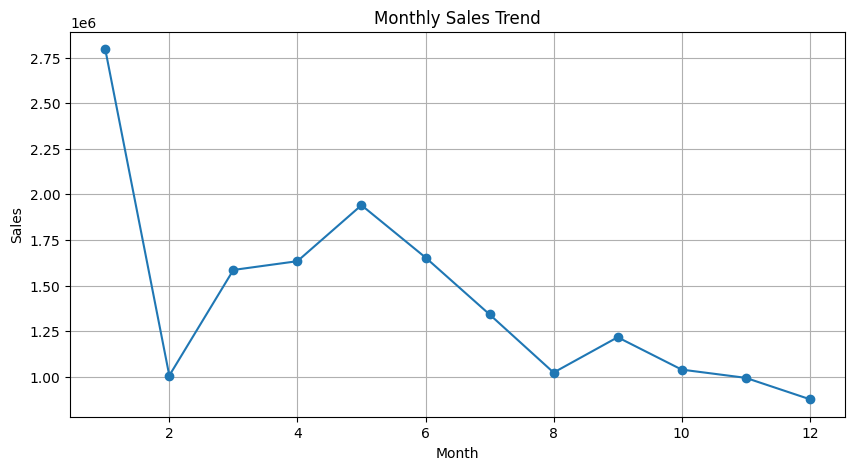

In [21]:
monthly_sales = data.groupby("Month")["Sales"].sum()
monthly_sales.plot(kind="line", marker="o", figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid()
plt.show()

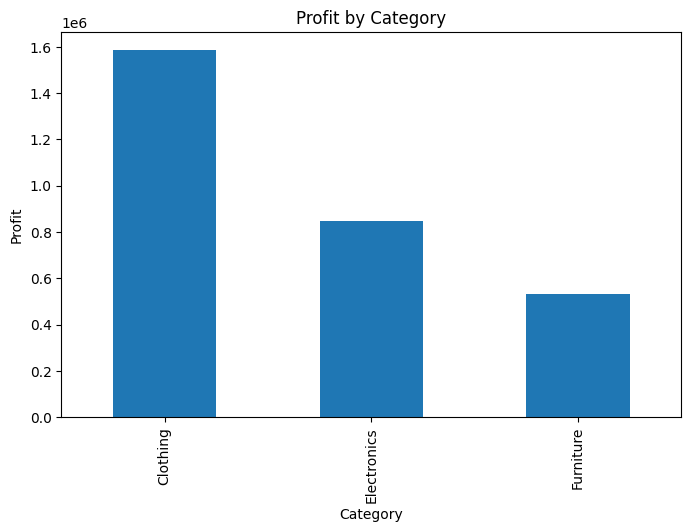

In [22]:
category_profit = data.groupby("Category")["Profit"].sum()
category_profit.plot(kind="bar", figsize=(8,5))
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

In [23]:
monthly_sales = data.groupby("Month")["Sales"].sum().reset_index()
print(monthly_sales)

    Month      Sales
0       1  2795560.0
1       2  1006010.0
2       3  1585270.0
3       4  1633350.0
4       5  1940365.0
5       6  1653530.0
6       7  1341460.0
7       8  1022600.0
8       9  1216240.0
9      10  1038790.0
10     11   993650.0
11     12   876455.0


In [24]:
from sklearn.linear_model import LinearRegression
X = monthly_sales[["Month"]]
y = monthly_sales["Sales"]
model = LinearRegression()
model.fit(X, y)
prediction = model.predict(pd.DataFrame({"Month": [15]}))
print("Predicted Sales for Month 15:", prediction[0])

Predicted Sales for Month 15: 527790.1340326341


In [25]:
correlation = data.corr(numeric_only=True)
print(correlation)

            Order_ID  Quantity  Discount  Unit_Price     Sales    Profit  \
Order_ID    1.000000 -0.038101  0.014928   -0.063189 -0.144852 -0.139457   
Quantity   -0.038101  1.000000 -0.065666   -0.050492  0.357109  0.339054   
Discount    0.014928 -0.065666  1.000000   -0.000656 -0.094590 -0.100533   
Unit_Price -0.063189 -0.050492 -0.000656    1.000000  0.818135  0.780824   
Sales      -0.144852  0.357109 -0.094590    0.818135  1.000000  0.952443   
Profit     -0.139457  0.339054 -0.100533    0.780824  0.952443  1.000000   
Month       0.581912 -0.041168  0.053045   -0.060544 -0.098288 -0.091804   

               Month  
Order_ID    0.581912  
Quantity   -0.041168  
Discount    0.053045  
Unit_Price -0.060544  
Sales      -0.098288  
Profit     -0.091804  
Month       1.000000  


In [26]:
print(data.shape)

(400, 11)


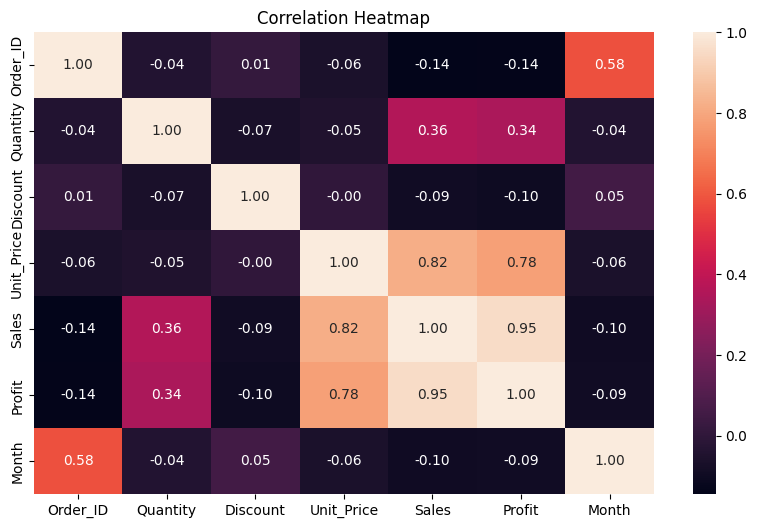

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
correlation = data.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

In [28]:
best_product = product_sales.idxmax()
print("Highest Selling Product:", best_product)
best_category = category_sales.idxmax()
print("Highest Selling Category:", best_category)
best_location = location_sales.idxmax()
print("Highest Selling Location:", best_location)
best_profit_category = category_profit.idxmax()
print("Highest Profit Category:", best_profit_category)
best_month = monthly_sales.idxmax()
print("Best Sales Month:", best_month)
lowest_month = monthly_sales.idxmin()
print("Lowest Sales Month:", lowest_month)

Highest Selling Product: Laptop
Highest Selling Category: Clothing
Highest Selling Location: Jaipur
Highest Profit Category: Clothing
Best Sales Month: Month    11
Sales     0
dtype: int64
Lowest Sales Month: Month     0
Sales    11
dtype: int64


In [29]:
data["Month"] = data["Order_Date"].dt.month
X = data[["Quantity", "Discount", "Unit_Price", "Month"]]
y = data["Sales"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 17057.26107212797
RMSE: 23027.34864542312
R² Score: 0.7917429935236184


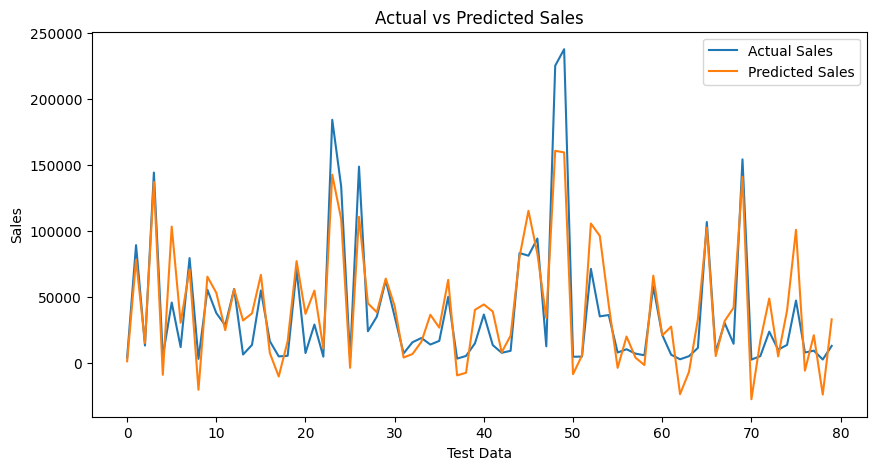

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label="Actual Sales")
plt.plot(y_pred, label="Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Data")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [31]:
print("===== FINAL BUSINESS INSIGHTS =====")
print("Highest Selling Product:", product_sales.idxmax())
print("Highest Selling Category:", category_sales.idxmax())
print("Highest Selling Location:", location_sales.idxmax())
print("Highest Profit Category:", category_profit.idxmax())
print("Best Sales Month:", monthly_sales.idxmax())
print("Lowest Sales Month:", monthly_sales.idxmin())
print("Model MAE:", mae)
print("Model RMSE:", rmse)
print("Model R² Score:", r2)

===== FINAL BUSINESS INSIGHTS =====
Highest Selling Product: Laptop
Highest Selling Category: Clothing
Highest Selling Location: Jaipur
Highest Profit Category: Clothing
Best Sales Month: Month    11
Sales     0
dtype: int64
Lowest Sales Month: Month     0
Sales    11
dtype: int64
Model MAE: 17057.26107212797
Model RMSE: 23027.34864542312
Model R² Score: 0.7917429935236184


In [ ]:
print(data["Month"].unique())

[ 1  2  3  4  5  6  7  8  9 10 11 12]


In [32]:
monthly_sales = data.groupby("Month")["Sales"].sum()
print("Best Sales Month:", monthly_sales.idxmax())
print("Lowest Sales Month:", monthly_sales.idxmin())
print(monthly_sales)

Best Sales Month: 1
Lowest Sales Month: 12
Month
1     2795560.0
2     1006010.0
3     1585270.0
4     1633350.0
5     1940365.0
6     1653530.0
7     1341460.0
8     1022600.0
9     1216240.0
10    1038790.0
11     993650.0
12     876455.0
Name: Sales, dtype: float64


In [33]:
total_sales = data["Sales"].sum()
total_profit = data["Profit"].sum()
total_orders = len(data)
print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)

Total Sales: 17103280.0
Total Profit: 2964163.5483631766
Total Orders: 400


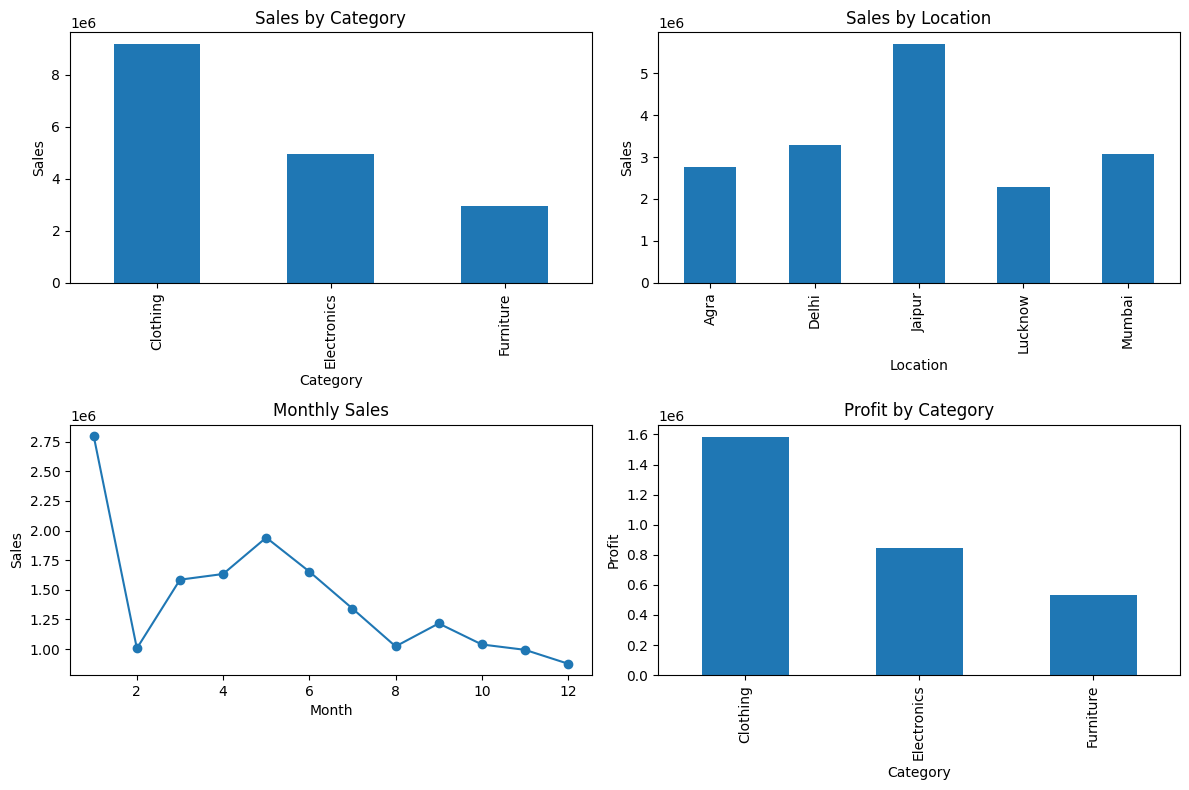

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.subplot(2, 2, 2)
location_sales.plot(kind="bar")
plt.title("Sales by Location")
plt.xlabel("Location")
plt.ylabel("Sales")

plt.subplot(2, 2, 3)
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.subplot(2, 2, 4)
category_profit.plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

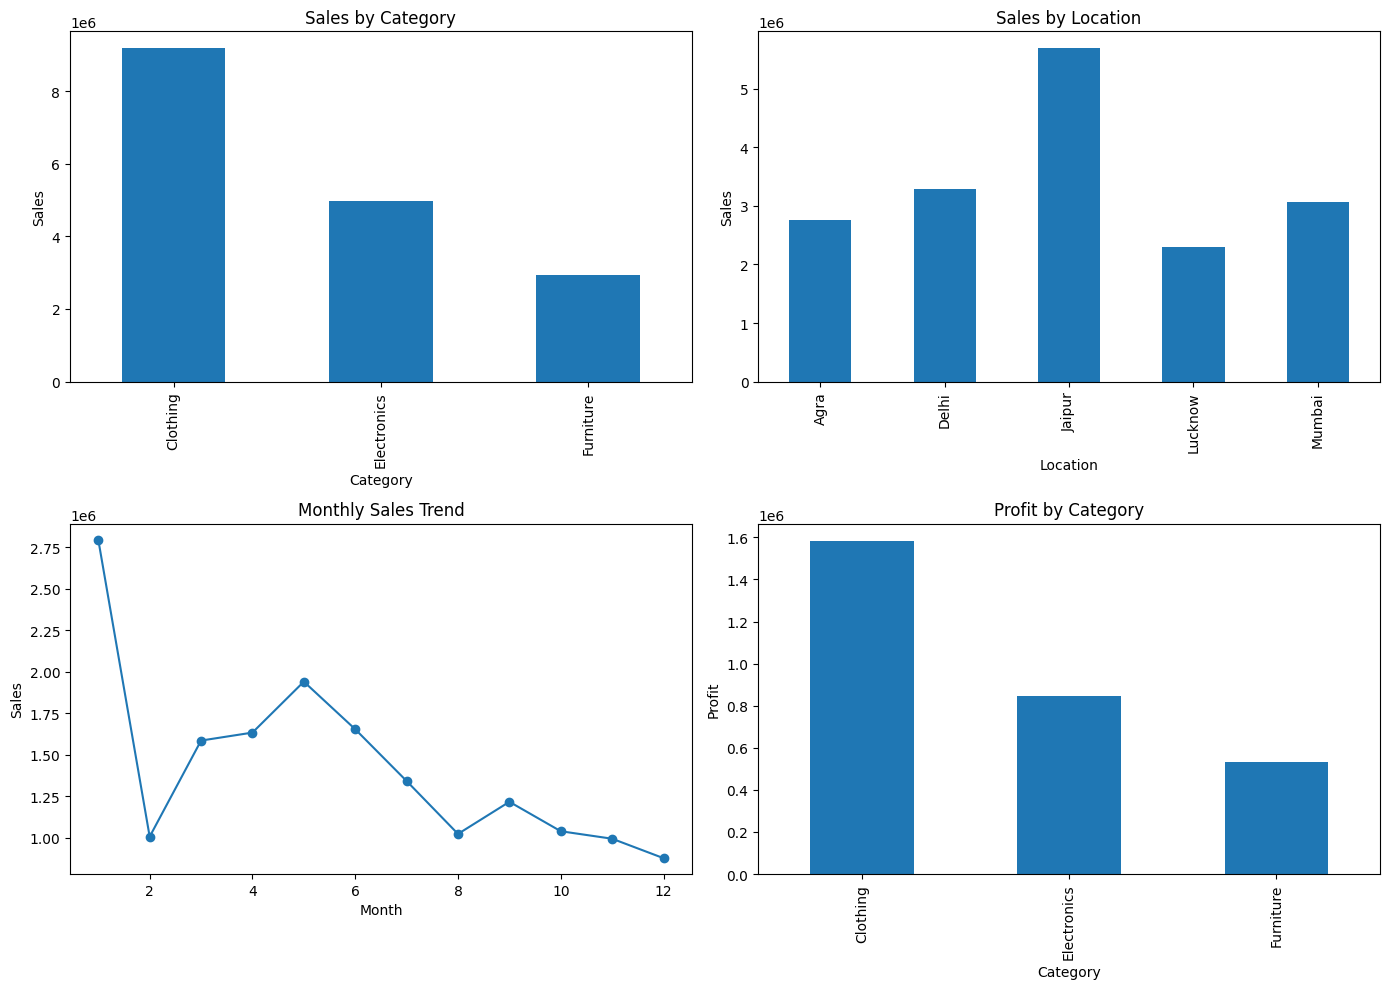

========== RETAIL SALES SUMMARY ==========
Total Sales: 17103280.0
Total Profit: 2964163.5483631766
Total Orders: 400


In [35]:
import matplotlib.pyplot as plt

# Calculate summary values
total_sales = data["Sales"].sum()
total_profit = data["Profit"].sum()
total_orders = len(data)

# Create dashboard
plt.figure(figsize=(14, 10))

# 1. Sales by Category
plt.subplot(2, 2, 1)
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

# 2. Sales by Location
plt.subplot(2, 2, 2)
location_sales.plot(kind="bar")
plt.title("Sales by Location")
plt.xlabel("Location")
plt.ylabel("Sales")

# 3. Monthly Sales
plt.subplot(2, 2, 3)
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

# 4. Profit by Category
plt.subplot(2, 2, 4)
category_profit.plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

# Display summary
print("========== RETAIL SALES SUMMARY ==========")
print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)

In [37]:
data.to_csv("retail_sales.csv", index=False)
from google.colab import files
files.download("retail_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>